In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np

In [2]:
samples = [
    "2Mu2E_100GeV_5p0GeV_4p0mm_iso",
    "2Mu2E_100GeV_5p0GeV_200mm_iso",
    "2Mu2E_1000GeV_0p25GeV_0p02mm_iso",
    "2Mu2E_1000GeV_0p25GeV_1p0mm_iso",

    "TTJets_iso",
    "QCD_Pt80To120_iso", 
    # "QCD_Pt120To170",
    "QCD_Pt170To300_iso", 
    "QCD_Pt300To470_iso",
    "QCD_Pt470To600_iso", 
    "QCD_Pt600To800_iso", 
    # "QCD_Pt800To1000",
    "QCD_Pt1000_iso", 
    "DYJetsToMuMu_M10to50_iso",
    "DYJetsToMuMu_M50_iso", 
]

In [3]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = "output_" + sample + ".coffea"
        try: 
            output = coffea.util.load(filename)
            print("Successfully opened file")        
            # out[sample] = output["out"][sample]
            out[sample] = output["out"][sample.removesuffix("_iso")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for sample 2Mu2E_100GeV_5p0GeV_4p0mm_iso
Successfully opened file
Loading file for sample 2Mu2E_100GeV_5p0GeV_200mm_iso
Successfully opened file
Loading file for sample 2Mu2E_1000GeV_0p25GeV_0p02mm_iso
Successfully opened file
Loading file for sample 2Mu2E_1000GeV_0p25GeV_1p0mm_iso
Successfully opened file
Loading file for sample TTJets_iso
Successfully opened file
Loading file for sample QCD_Pt80To120_iso
Successfully opened file
Loading file for sample QCD_Pt170To300_iso
Successfully opened file
Loading file for sample QCD_Pt300To470_iso
Successfully opened file
Loading file for sample QCD_Pt470To600_iso
Successfully opened file
Loading file for sample QCD_Pt600To800_iso
Successfully opened file
Loading file for sample QCD_Pt1000_iso
Successfully opened file
Loading file for sample DYJetsToMuMu_M10to50_iso
Successfully opened file
Loading file for samp

In [4]:
samples = [
    "2Mu2E_100GeV_5p0GeV_4p0mm_disp",
    "2Mu2E_100GeV_5p0GeV_200mm_disp",
    "2Mu2E_1000GeV_0p25GeV_0p02mm_disp",
    "2Mu2E_1000GeV_0p25GeV_1p0mm_disp",

    "TTJets_disp",
    "QCD_Pt80To120_disp", 
    # "QCD_Pt120To170",
    "QCD_Pt170To300_disp", 
    "QCD_Pt300To470_disp",
    "QCD_Pt470To600_disp", 
    "QCD_Pt600To800_disp", 
    # "QCD_Pt800To1000",
    "QCD_Pt1000_disp", 
    "DYJetsToMuMu_M10to50_disp",
    "DYJetsToMuMu_M50_disp", 
]

In [5]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = "output_" + sample + ".coffea"
        try: 
            output = coffea.util.load(filename)
            print("Successfully opened file")        
            # out[sample] = output["out"][sample]
            out[sample] = output["out"][sample.removesuffix("_disp")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample 2Mu2E_100GeV_5p0GeV_4p0mm_disp
Successfully opened file
Loading file for sample 2Mu2E_100GeV_5p0GeV_200mm_disp
Successfully opened file
Loading file for sample 2Mu2E_1000GeV_0p25GeV_0p02mm_disp
Successfully opened file
Loading file for sample 2Mu2E_1000GeV_0p25GeV_1p0mm_disp
Successfully opened file
Loading file for sample TTJets_disp
Successfully opened file
Loading file for sample QCD_Pt80To120_disp
Successfully opened file
Loading file for sample QCD_Pt170To300_disp
Successfully opened file
Loading file for sample QCD_Pt300To470_disp
Successfully opened file
Loading file for sample QCD_Pt470To600_disp
Successfully opened file
Loading file for sample QCD_Pt600To800_disp
Successfully opened file
Loading file for sample QCD_Pt1000_disp
Successfully opened file
Loading file for sample DYJetsToMuMu_M10to50_disp
Successfully opened file
Loading file for sample DYJetsToMuMu_M50_disp
Su

In [19]:
from cycler import cycler

channels_main = [
    "baseNoLj_No_Muon_Constraint",
    "baseNoLj_Two_Ormore_Muon",
    "baseNoLj_Two_Ormore_Muon_Displacement",
]

channels_iso = [
    "baseNoLj_Two_Ormore_Muon_Displacement_EgmIso",
    "baseNoLj_Two_Ormore_Muon_Displacement_MuIso",
    "baseNoLj_Two_Ormore_Muon_Displacement_EgmIso_MuIso",
]

legend = [
    "Baseline",
    "Muon >= 2",
    "Muon >= 2 + Disp",
    "Muon >= 2 + Disp + EGM Iso",
    "Muon >= 2 + Disp + Mu Iso",
    "Muon >= 2 + Disp + Both Iso",
]

colors = [
    "r",
    "g",
    "b",
    "darkorange",
    "cyan",
]

plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

In [15]:
def plot_ratio_wrapper_two_samples(
    out,
    sample_main,
    sample_iso,
    hist_name,
    channels_main,
    channels_iso,
    legend,
    hist_range,
    text_x,
    text_y=3,
    ylabel="Arbitrary Units",
):

    hists_main = out[sample_main]["hists"][hist_name]
    hists_iso  = out[sample_iso]["hists"][hist_name]

    # denominator: first channel from main sample
    den = hists_main[channels_main[0], hist_range]

    # numerators:
    # main sample except baseline
    num_list = [hists_main[ch, hist_range] for ch in channels_main[1:]]

    # iso sample channels
    num_list += [hists_iso[ch, hist_range] for ch in channels_iso]

    expected_legend_len = 1 + len(num_list)
    if len(legend) != expected_legend_len:
        raise ValueError(
            f"Legend length mismatch: got {len(legend)}, "
            f"but expected {expected_legend_len}. "
            f"(1 baseline + {len(num_list)} numerator histograms)"
        )

    utilities.plot_ratio(
        num_list,
        den,
        legend=legend,
        ylabel=ylabel,
        text=""
    )

    # use main sample name as label, removing common suffixes
    sample_label = sample_main.replace("_disp", "").replace("_iso", "")
    plt.text(text_x, text_y, sample_label)

In [16]:
def sum_bgs_hist(bgs_list, histogram_name, channel_name):
    """
    Sum histograms for a list of backgrounds.
    """
    summed_hist = None
    
    for x in bgs_list:
        # print(x)
        hist = out[x]["hists"][histogram_name][channel_name, :]
        
        if summed_hist is None:
            summed_hist = hist.copy()
        else:
            summed_hist += hist
    
    return summed_hist

In [57]:
import math
import mplhep as hep

def plot_ratio_panels_two_samples(
    out,
    samples_main,
    samples_iso,
    histname,
    channels_main,
    channels_iso,
    legend,
    **kwargs
):

    n_panels = len(samples_main)

    if n_panels == 0:
        raise ValueError("Empty samples_main!")

    if len(samples_iso) != n_panels:
        raise ValueError("samples_main and samples_iso must have the same length")

    expected_legend_len = 1 + len(channels_main[1:]) + len(channels_iso)
    if len(legend) != expected_legend_len:
        raise ValueError(
            f"Legend length mismatch: got {len(legend)}, "
            f"expected {expected_legend_len}"
        )

    ncols = kwargs.get("ncols", 3)
    n_sample_rows = math.ceil(n_panels / ncols)
    nrows = 2 * n_sample_rows

    ylabel = kwargs.get("ylabel", None)
    eff_ylim = kwargs.get("eff_ylim", (0, 1.2))
    ylims = kwargs.get("ylims", [None] * n_panels)
    flow = kwargs.get("flow", "none")
    logy = kwargs.get("logy", False)
    main_histtype = kwargs.get("main_histtype", None)
    ratio_histtype = kwargs.get("ratio_histtype", "errorbar")

    titles = kwargs.get(
        "titles",
        [
            s.replace("QCD_", "").replace("DY_", "").replace("_disp", "").replace("_iso", "")
            for s in samples_main
        ]
    )

    figsize = kwargs.get(
        "figsize",
        (14 * ncols, 9 * n_sample_rows + 5 * n_sample_rows)
    )

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex='col',
        squeeze=False,
        gridspec_kw={
            'height_ratios': [3, 1] * n_sample_rows,
            'hspace': 0,
            'wspace': 0.25
        }
    )

    for i, (sample_main, sample_iso) in enumerate(zip(samples_main, samples_iso)):
        col = i % ncols
        block = i // ncols

        ax1 = axes[2 * block, col]
        ax2 = axes[2 * block + 1, col]

        h_main = out[sample_main]["hists"][histname]
        h_iso  = out[sample_iso]["hists"][histname]

        den = h_main[channels_main[0], :]

        nums = [h_main[ch, :] for ch in channels_main[1:]]
        nums += [h_iso[ch, :] for ch in channels_iso]

        plt.sca(ax1)

        main_kwargs = dict(flow=flow, color='k', label=legend[0])
        if main_histtype is not None:
            main_kwargs["histtype"] = main_histtype
        hep.histplot(den, **main_kwargs)

        for j, x in enumerate(nums):
            num_kwargs = dict(flow=flow, label=legend[j + 1])
            if main_histtype is not None:
                num_kwargs["histtype"] = main_histtype
            hep.histplot(x, **num_kwargs)

        ax1.legend(fontsize=20)
        ax1.set_title(titles[i])

        if ylims[i] is not None:
            ax1.set_ylim(ylims[i])

        if logy:
            ax1.set_yscale("log")

        if col == 0 and ylabel is not None:
            ax1.set_ylabel(ylabel)

        plt.sca(ax2)

        for x in nums:
            eff, errors = utilities.get_eff_hist(x, den)
            hep.histplot(
                eff,
                histtype=ratio_histtype,
                yerr=errors
            )

        if col == 0:
            ax2.set_ylabel("Efficiency")

        ax2.set_ylim(*eff_ylim)

    total_slots = n_sample_rows * ncols
    for i in range(n_panels, total_slots):
        col = i % ncols
        block = i // ncols
        axes[2 * block, col].set_visible(False)
        axes[2 * block + 1, col].set_visible(False)

    plt.tight_layout()
    return fig, axes

## LJ muon cut test version 3
### We conclude that `number of muons in LJ >= 2 + Displacement` is our final choice in the previous notebook.
### Let's take a final check including isolation cut

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

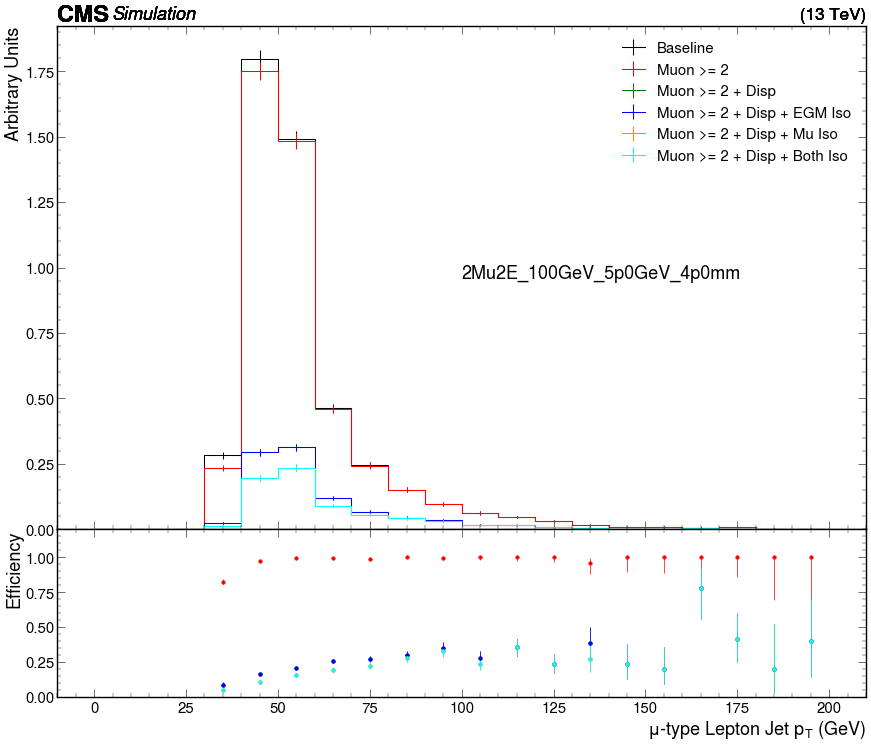

In [21]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_100GeV_5p0GeV_4p0mm_disp",
    sample_iso="2Mu2E_100GeV_5p0GeV_4p0mm_iso",
    hist_name="mu_lj_pt",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None, 200j),
    text_x=100,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

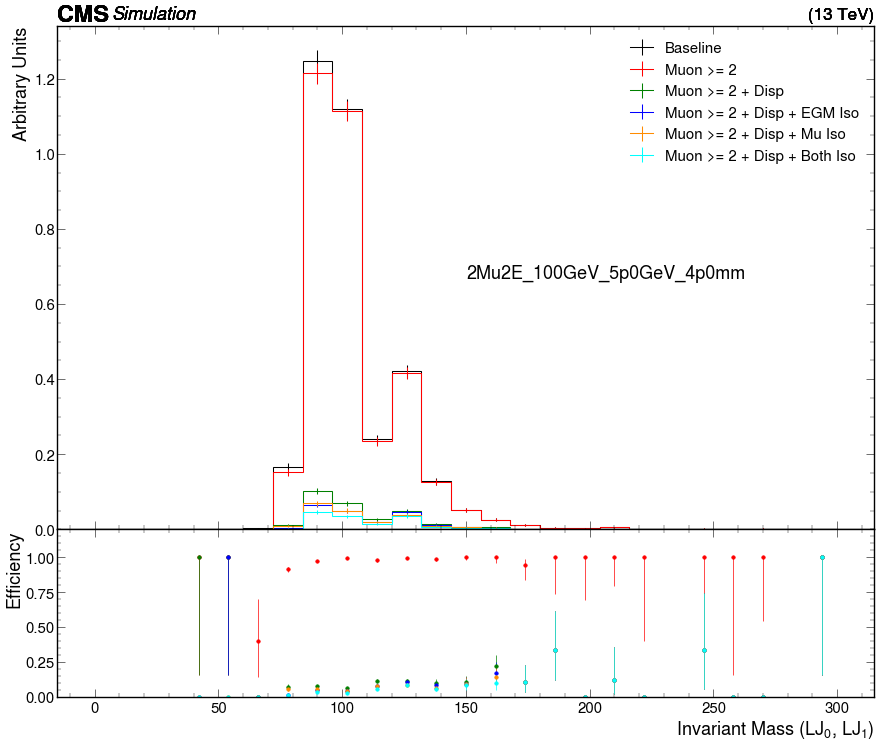

In [35]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_100GeV_5p0GeV_4p0mm_disp",
    sample_iso="2Mu2E_100GeV_5p0GeV_4p0mm_iso",
    hist_name="mulj_egmlj_invmass",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None, 300j),
    text_x=150,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

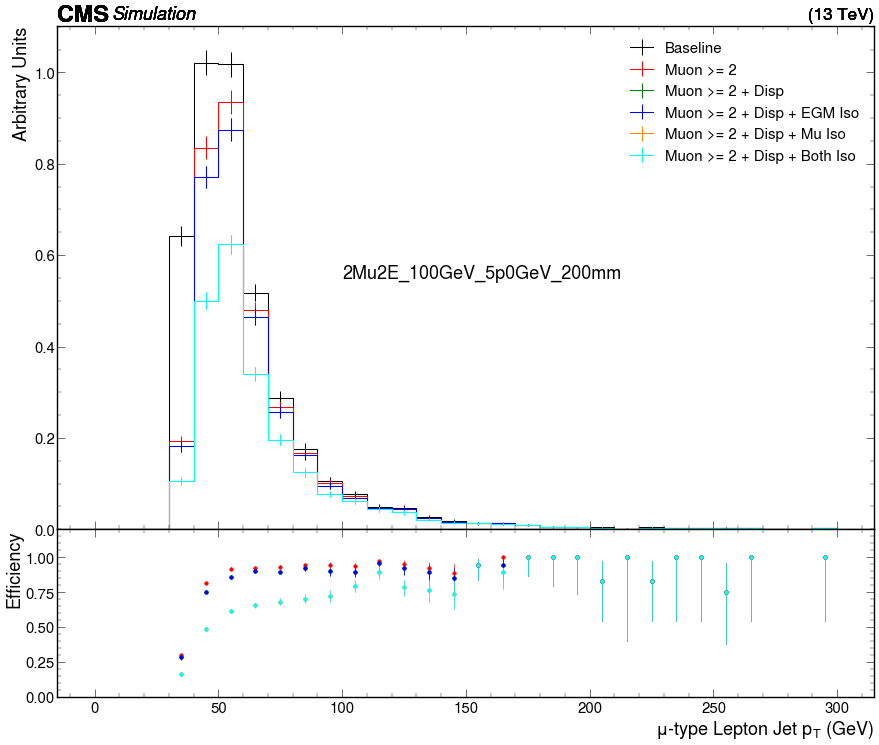

In [23]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_100GeV_5p0GeV_200mm_disp",
    sample_iso="2Mu2E_100GeV_5p0GeV_200mm_iso",
    hist_name="mu_lj_pt",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None, 300j),
    text_x=100,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

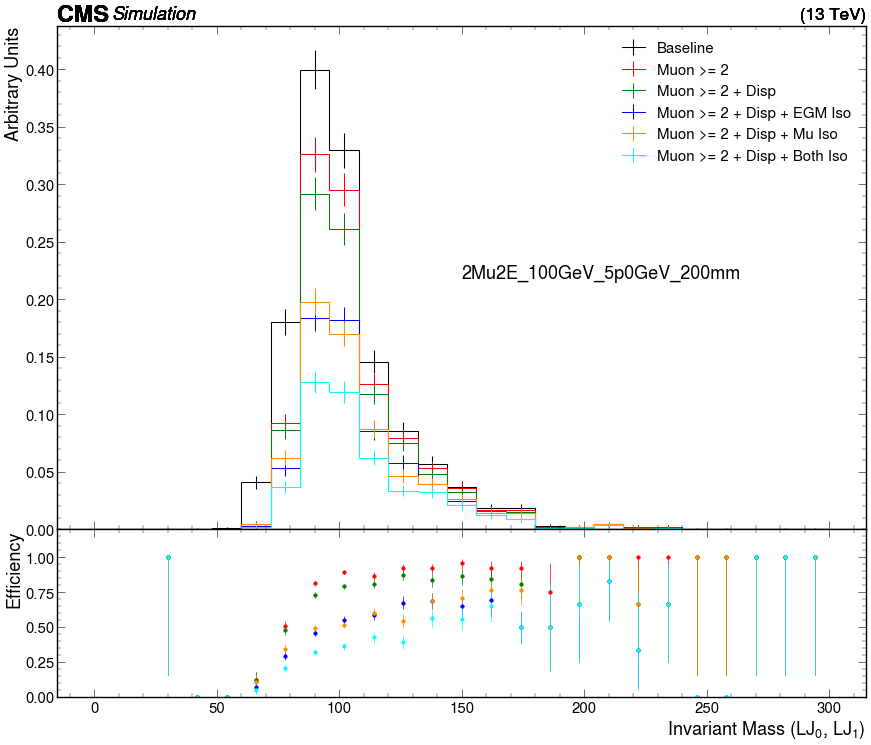

In [37]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_100GeV_5p0GeV_200mm_disp",
    sample_iso="2Mu2E_100GeV_5p0GeV_200mm_iso",
    hist_name="mulj_egmlj_invmass",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None, 300j),
    text_x=150,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

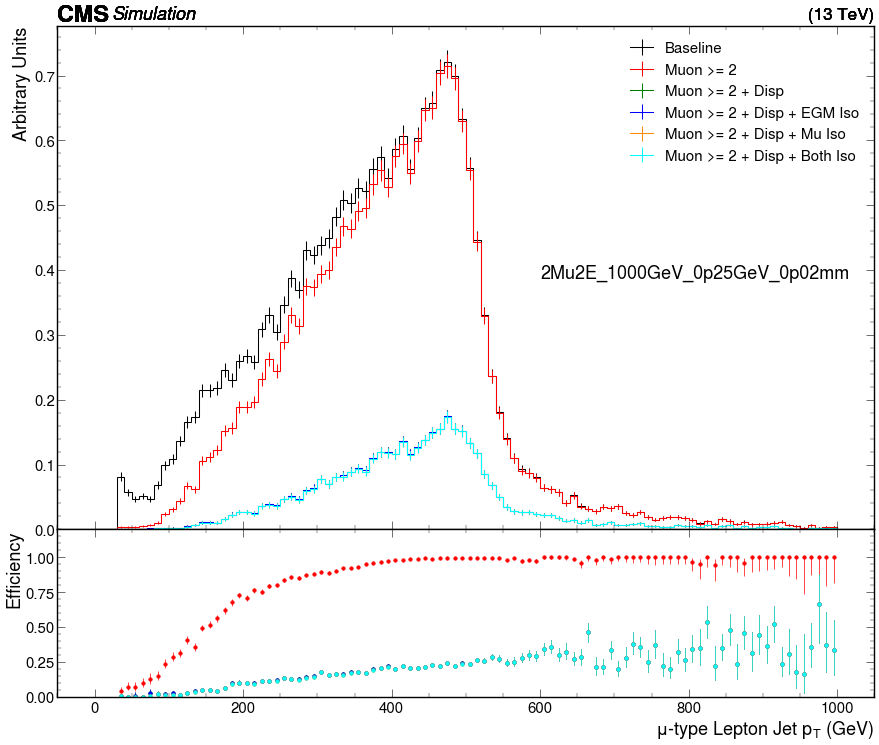

In [26]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_1000GeV_0p25GeV_0p02mm_disp",
    sample_iso="2Mu2E_1000GeV_0p25GeV_0p02mm_iso",
    hist_name="mu_lj_pt",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None),
    text_x=600,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()


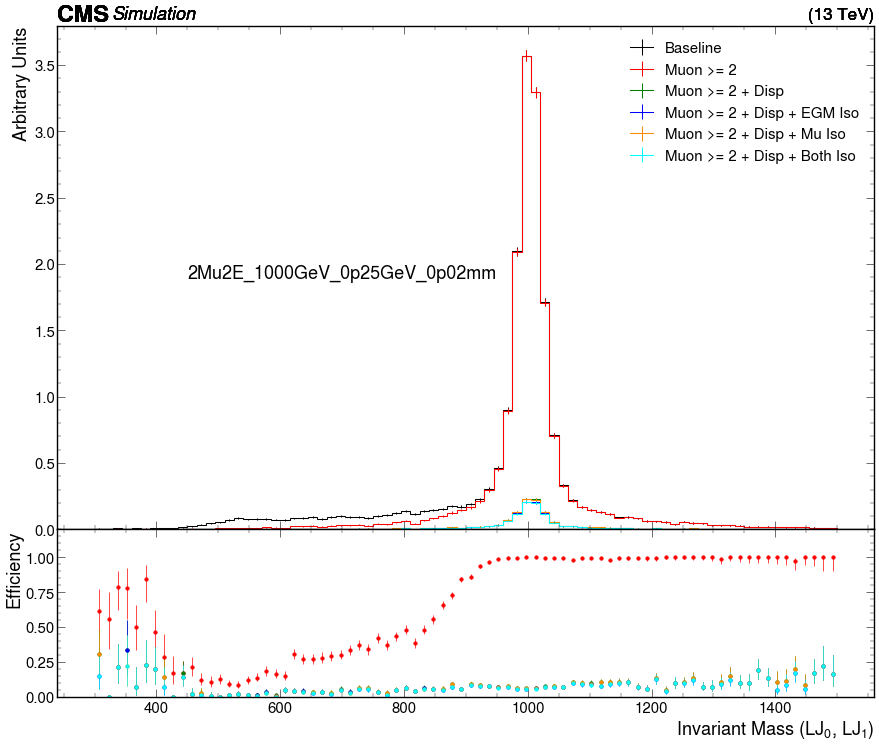

In [44]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_1000GeV_0p25GeV_0p02mm_disp",
    sample_iso="2Mu2E_1000GeV_0p25GeV_0p02mm_iso",
    hist_name="mulj_egmlj_invmass",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(300j, None),
    text_x=450,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

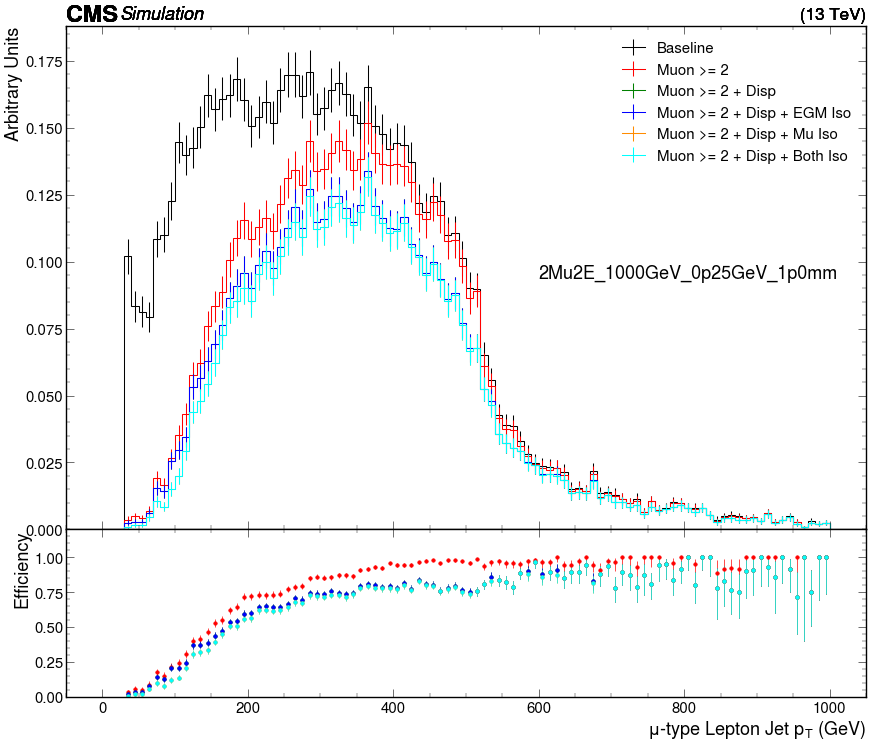

In [30]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_1000GeV_0p25GeV_1p0mm_disp",
    sample_iso="2Mu2E_1000GeV_0p25GeV_1p0mm_iso",
    hist_name="mu_lj_pt",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None),
    text_x=600,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

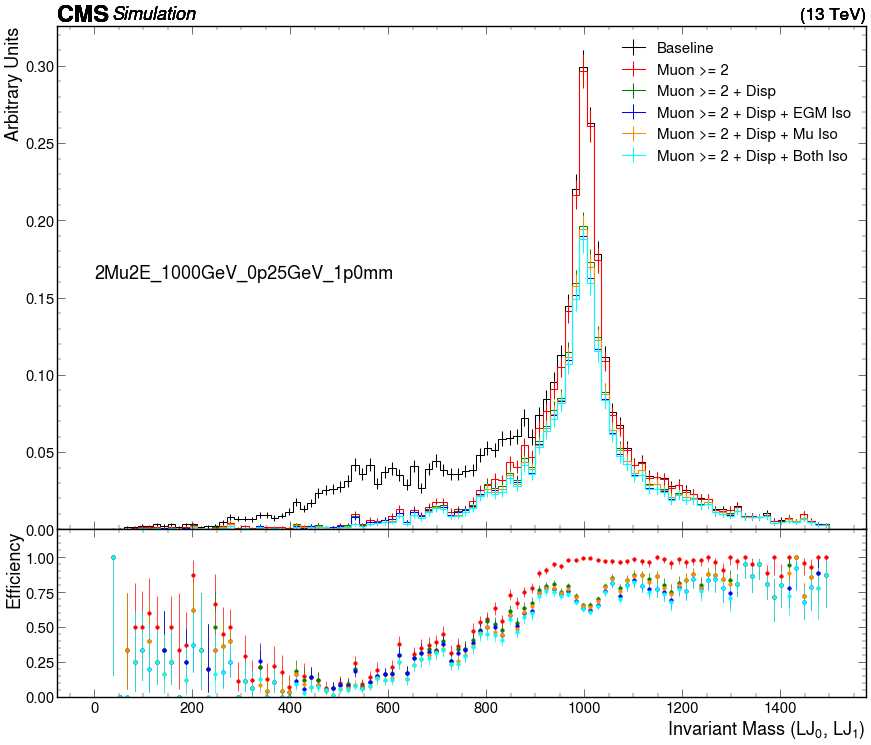

In [43]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="2Mu2E_1000GeV_0p25GeV_1p0mm_disp",
    sample_iso="2Mu2E_1000GeV_0p25GeV_1p0mm_iso",
    hist_name="mulj_egmlj_invmass",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None),
    text_x=1.2,
    text_y=3,
)

### Okay, isolation cut hurts the signal more than expected, especially in promptly decaying samples.
### While it is still too early to draw definitive conclusions, the results so far suggest that samples with small BS and short decay lengths tend to be less isolated.
### Let's check with bkg as well

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

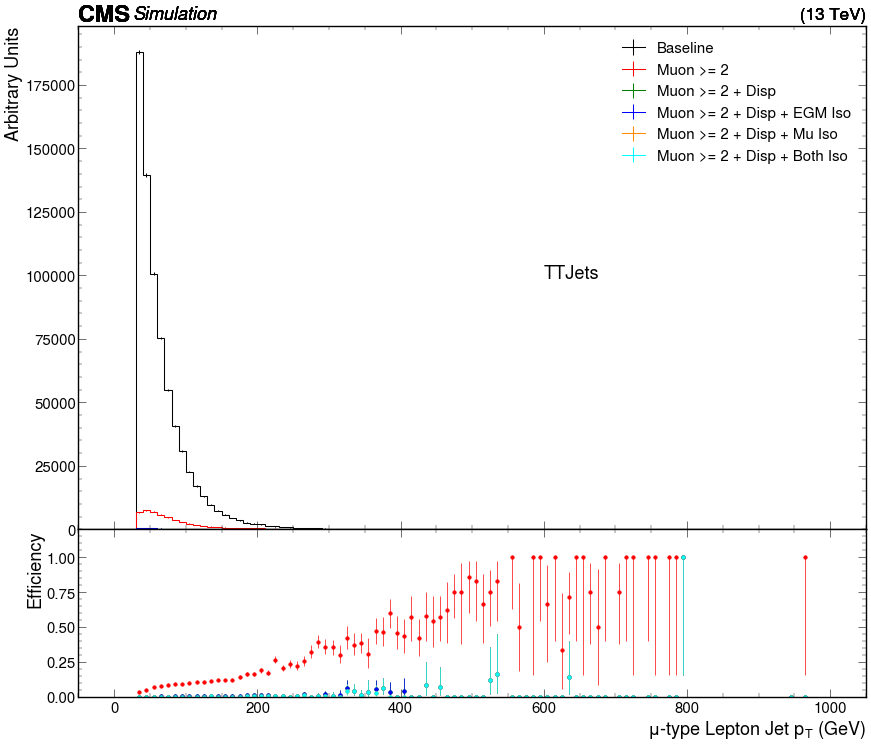

In [45]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="TTJets_disp",
    sample_iso="TTJets_iso",
    hist_name="mu_lj_pt",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None),
    text_x=600,
    text_y=3,
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

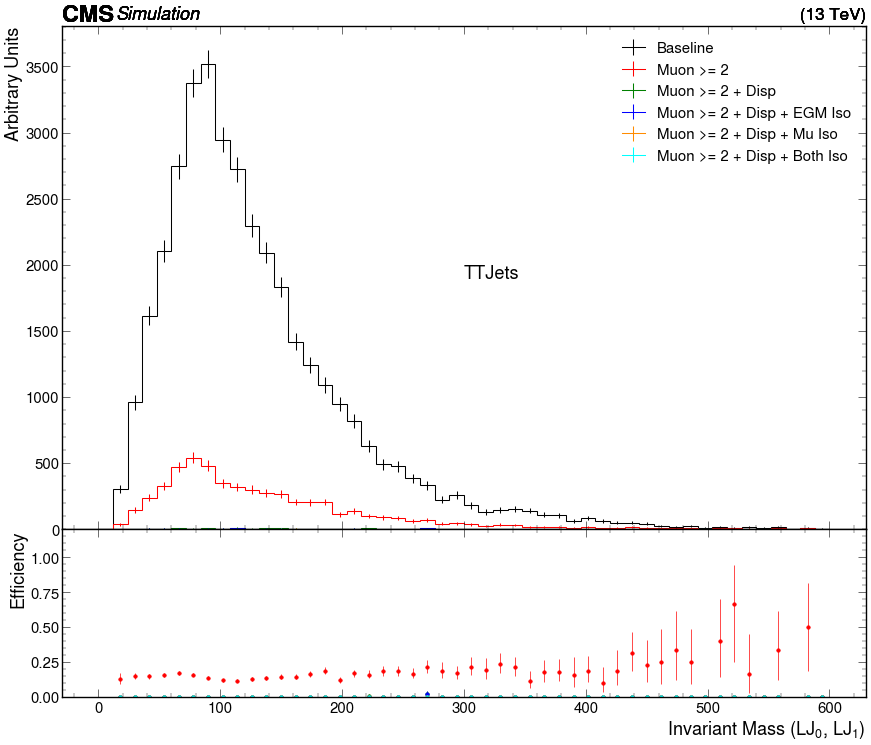

In [46]:
plot_ratio_wrapper_two_samples(
    out=out,
    sample_main="TTJets_disp",
    sample_iso="TTJets_iso",
    hist_name="mulj_egmlj_invmass",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    hist_range=slice(None, 600j),
    text_x=300,
    text_y=3,
)

In [58]:
QCD_main = [
    "QCD_Pt80To120_disp", 
    # "QCD_Pt120To170",
    "QCD_Pt170To300_disp", 
    "QCD_Pt300To470_disp",
    "QCD_Pt470To600_disp", 
    "QCD_Pt600To800_disp", 
    # "QCD_Pt800To1000",
    "QCD_Pt1000_disp", 
]

QCD_iso = [
    "QCD_Pt80To120_iso", 
    # "QCD_Pt120To170",
    "QCD_Pt170To300_iso", 
    "QCD_Pt300To470_iso",
    "QCD_Pt470To600_iso", 
    "QCD_Pt600To800_iso", 
    # "QCD_Pt800To1000",
    "QCD_Pt1000_iso", 
]

DY_main = [
    "DYJetsToMuMu_M10to50_disp", 
    "DYJetsToMuMu_M50_disp", 
]

DY_iso = [
    "DYJetsToMuMu_M10to50_iso", 
    "DYJetsToMuMu_M50_iso", 
]

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

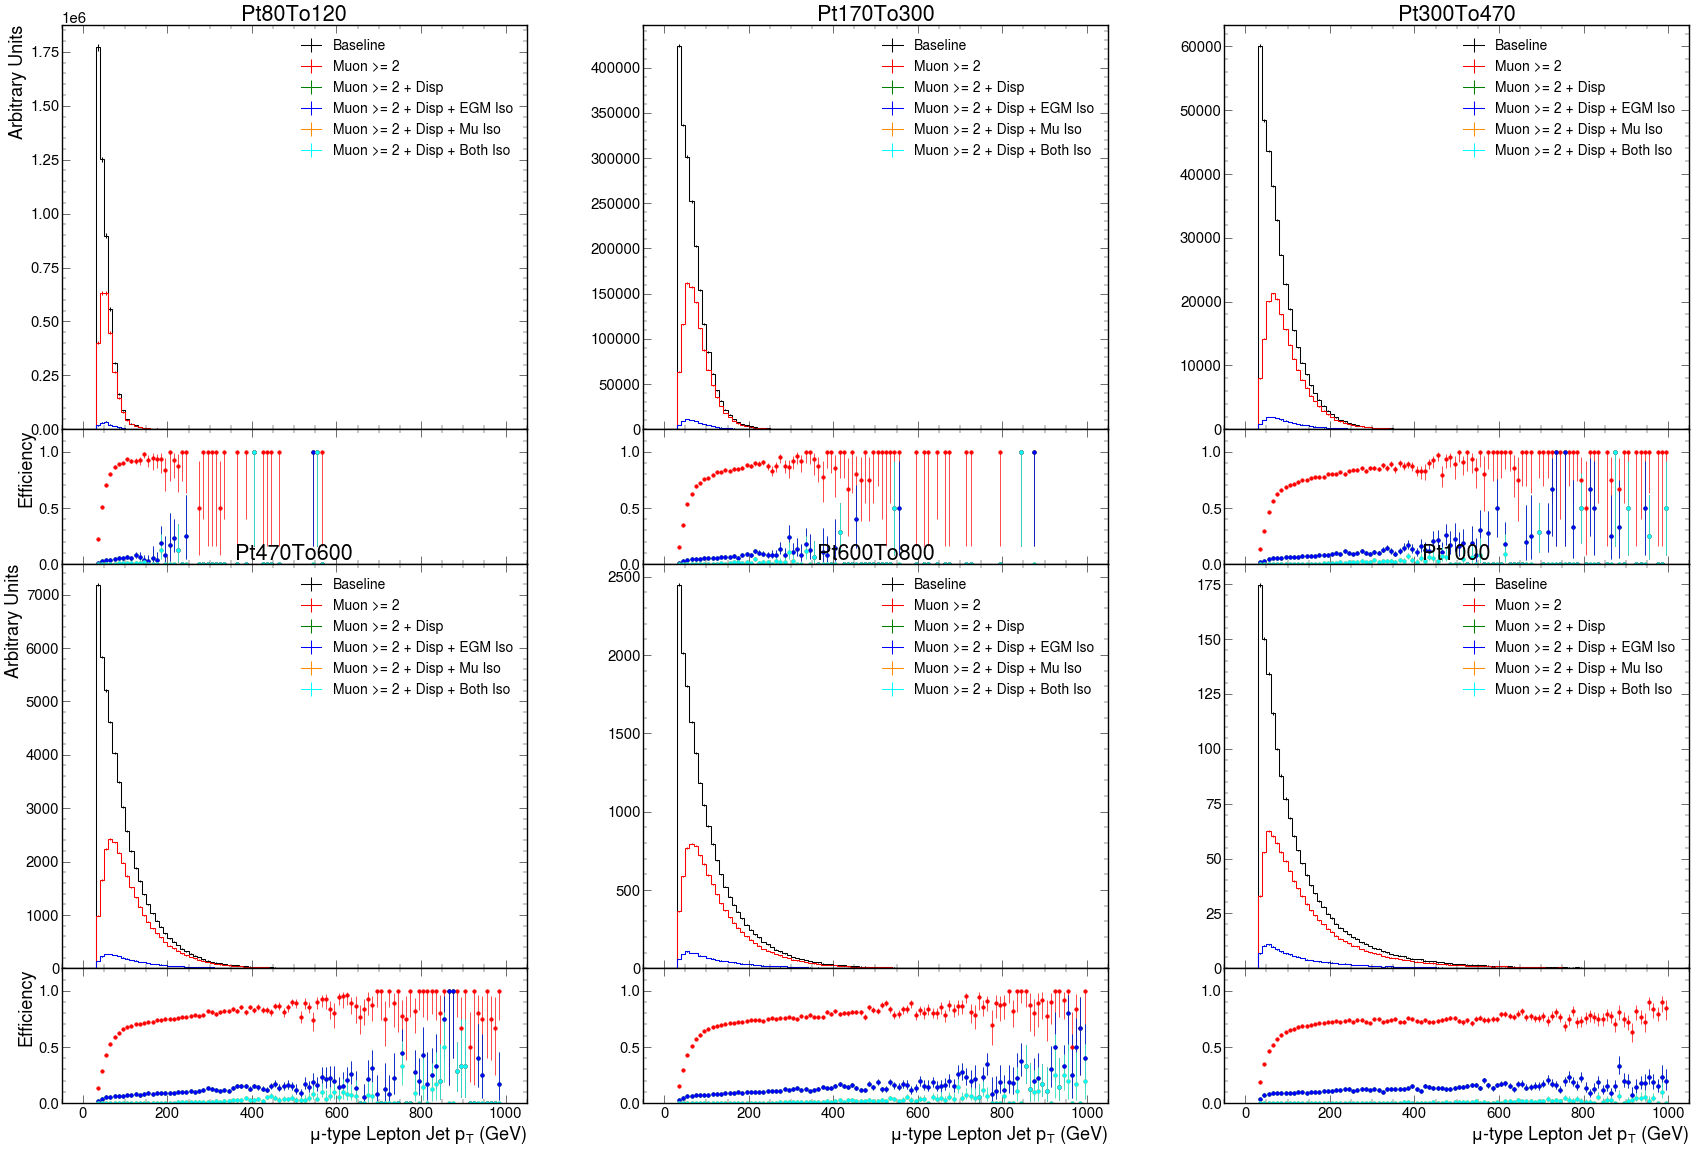

In [59]:
fig, axes = plot_ratio_panels_two_samples(
    out=out,
    samples_main=QCD_main,
    samples_iso=QCD_iso,
    histname="mu_lj_pt",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    ylabel="Arbitrary Units",
    ncols=3,
    eff_ylim=(0, 1.2),
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

ValueError: Found numerator larger than denominator while calculating binomial uncertainty

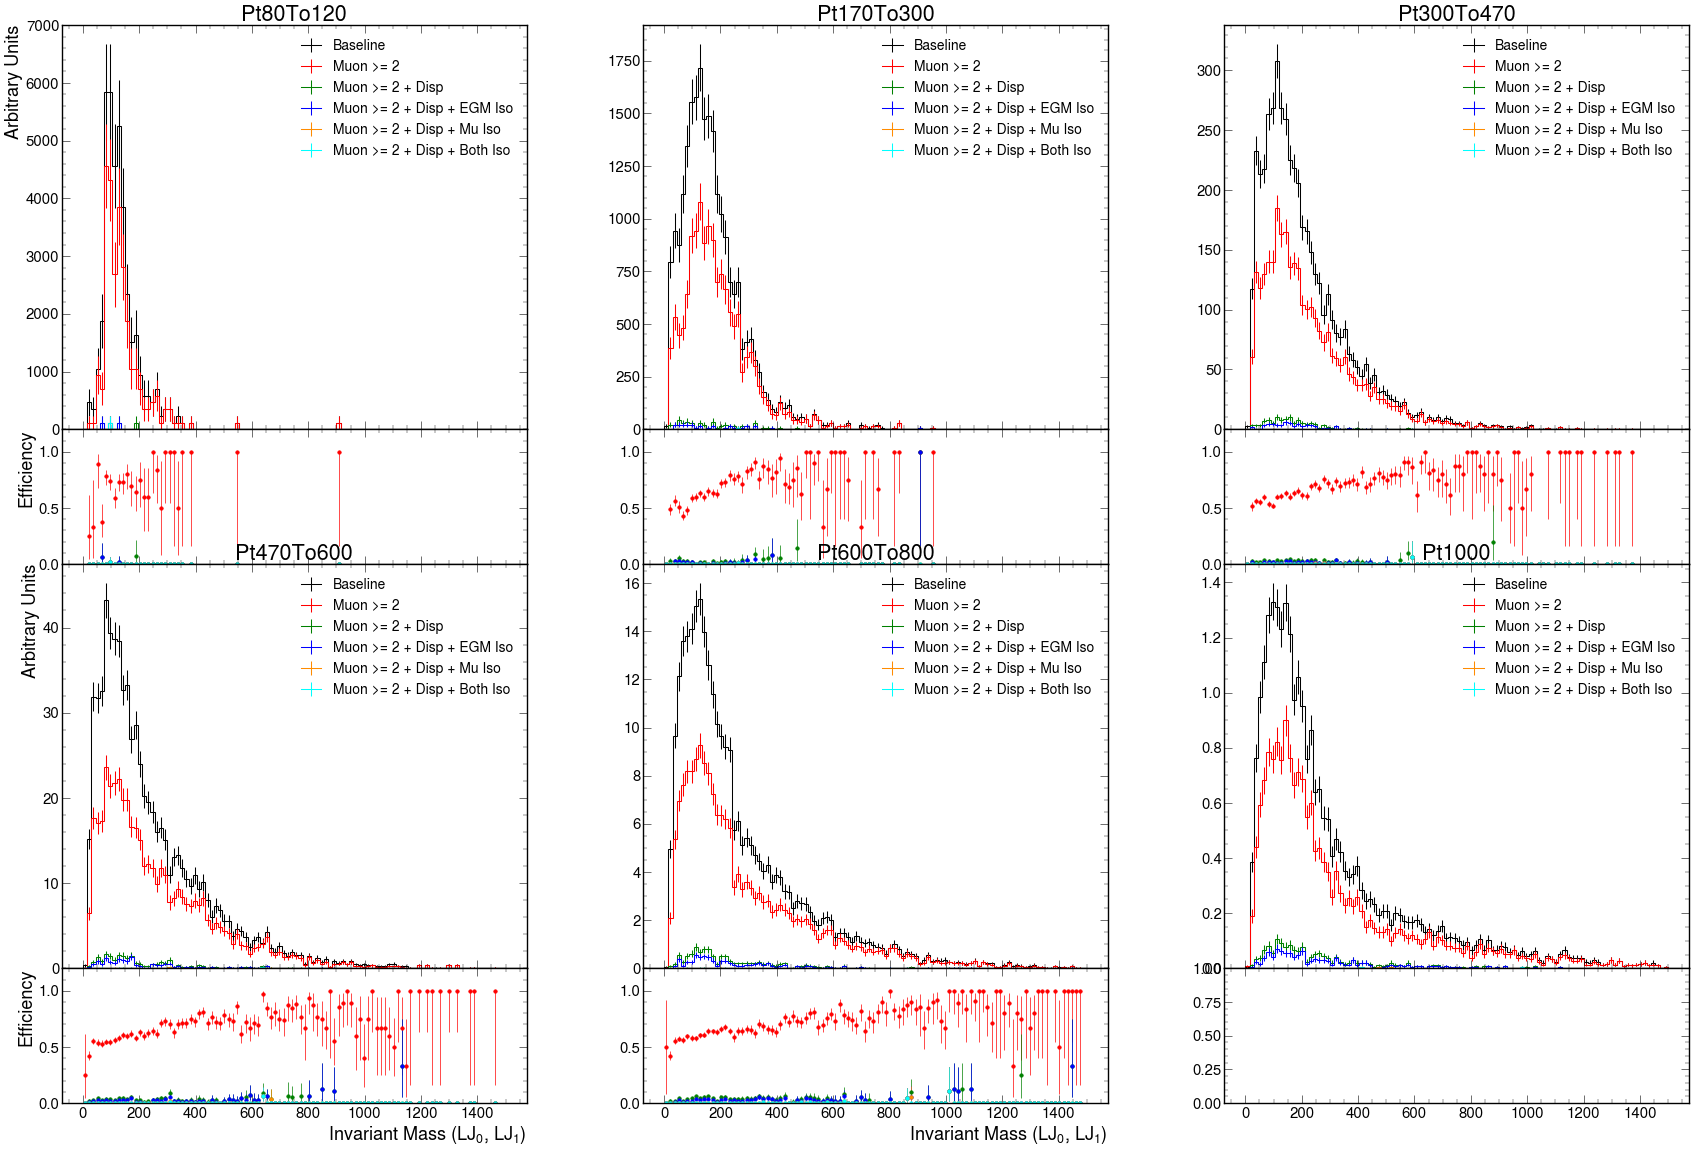

In [60]:
fig, axes = plot_ratio_panels_two_samples(
    out=out,
    samples_main=QCD_main,
    samples_iso=QCD_iso,
    histname="mulj_egmlj_invmass",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    ylabel="Arbitrary Units",
    ncols=3,
    eff_ylim=(0, 1.2),
)

/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:232: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:233: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

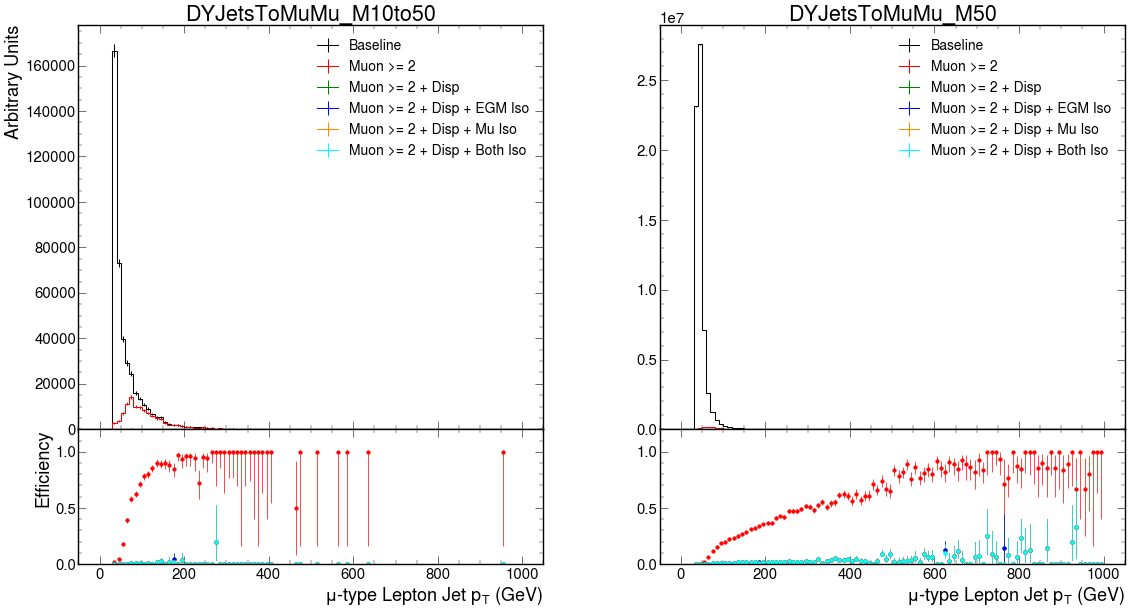

In [61]:
fig, axes = plot_ratio_panels_two_samples(
    out=out,
    samples_main=DY_main,
    samples_iso=DY_iso,
    histname="mu_lj_pt",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    ylabel="Arbitrary Units",
    ncols=3,
    eff_ylim=(0, 1.2),
)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:486: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/home/cms-jovyan/workspace/Updated2026/sidm/tools/utilities.py:227: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/Updated2026/sidm/t

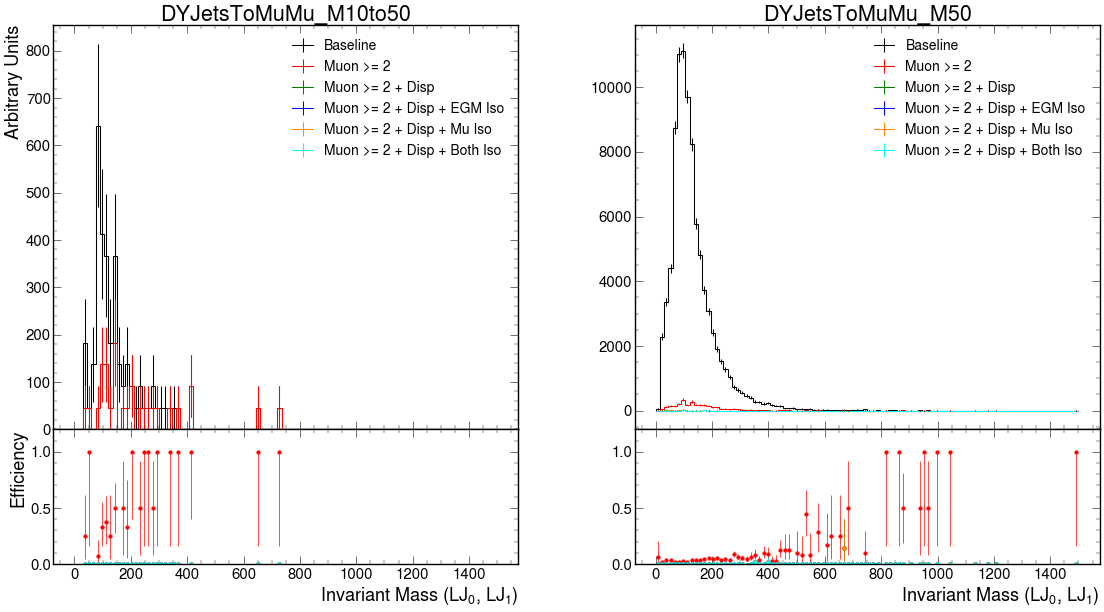

In [62]:
fig, axes = plot_ratio_panels_two_samples(
    out=out,
    samples_main=DY_main,
    samples_iso=DY_iso,
    histname="mulj_egmlj_invmass",
    channels_main=channels_main,
    channels_iso=channels_iso,
    legend=legend,
    ylabel="Arbitrary Units",
    ncols=3,
    eff_ylim=(0, 1.2),
)

### Most of the backgrounds are already vetoed by the displacement cut
### So, applying additional isolation cuts on the selection level might hurt the signal more than the backgrounds.
### My perspective is, we have to take one of the displacement or isolation as selection level, and pass other one to ABCD